In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from warnings import filterwarnings
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

In [2]:
#load data#
drug = pd.read_csv('drugs_rows.csv', encoding_errors='ignore')
#display(drug.head(5))

In [3]:
#Data Type -Unique values#
datatype = drug.dtypes
unic = drug.nunique()
display(pd.DataFrame({
    'datatype': datatype,
    'unic': unic
}).T)
#ratio is null
isnull = drug.isnull().sum()
ratio = 100 * isnull / drug.shape[0]

display(pd.DataFrame({'isnull': isnull, 'ratio': ratio}).T)

,id,source_id,commercial_name_en,commercial_name_ar,active_ingredients,manufacturer,current_price,previous_price,last_price_update_date,units,barcode,dosage_form,uses_ar,image_url,scraped_at,is_missing,missing_since
datatype,object,int64,object,object,object,object,float64,float64,object,int64,object,object,object,object,object,bool,float64
unic,14679,14679,14218,14321,5280,3590,1550,951,13131,22,5400,43,3022,2276,4531,1,0


,id,source_id,commercial_name_en,commercial_name_ar,active_ingredients,manufacturer,current_price,previous_price,last_price_update_date,units,barcode,dosage_form,uses_ar,image_url,scraped_at,is_missing,missing_since
isnull,0.0,0.0,0.0,0.0,1550.000000,145.000000,0.0,8815.000000,1528.000000,0.0,9062.000000,0.0,10434.000000,12329.000000,0.0,0.0,14679.0
ratio,0.0,0.0,0.0,0.0,10.559302,0.987806,0.0,60.051775,10.409428,0.0,61.734451,0.0,71.081136,83.990735,0.0,0.0,100.0


In [4]:
#handell missing value delet
#1-image_url col
#2-barcode col
#3-uses_ar
#4-missing_since col#
drug.drop(['image_url', 'barcode', 'uses_ar', 'missing_since'],
           axis=1, inplace=True, errors='ignore')
#حذف الصفوف التي تحتوي علي null
drug = drug.dropna(subset=['active_ingredients','last_price_update_date','manufacturer'])

drug.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11733 entries, 0 to 14678
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      11733 non-null  object 
 1   source_id               11733 non-null  int64  
 2   commercial_name_en      11733 non-null  object 
 3   commercial_name_ar      11733 non-null  object 
 4   active_ingredients      11733 non-null  object 
 5   manufacturer            11733 non-null  object 
 6   current_price           11733 non-null  float64
 7   previous_price          5389 non-null   float64
 8   last_price_update_date  11733 non-null  object 
 9   units                   11733 non-null  int64  
 10  dosage_form             11733 non-null  object 
 11  scraped_at              11733 non-null  object 
 12  is_missing              11733 non-null  bool   
dtypes: bool(1), float64(2), int64(2), object(8)
memory usage: 1.2+ MB


In [5]:
drug = drug.dropna(subset=['price_change_ratio'])
drug.columns = drug.columns.str.strip()

KeyError: ['price_change_ratio']

In [7]:
#بنعوض قيم null الموجود ب استخدام

# افترض إن الداتا موجودة في DataFrame اسمه drug
imputer = KNNImputer(n_neighbors=5)

# نطبق على previous_price و current_price مع بعض
imputed_values = imputer.fit_transform(drug[['previous_price', 'current_price']])

# نرجع previous_price بعد التعويض
drug['previous_price'] = imputed_values[:, 0]

# نتأكد إن previous_price مش أكبر من current_price
drug['previous_price'] = drug.apply(lambda row: min(row['previous_price'], row['current_price']), axis=1)

print(drug[['current_price', 'previous_price']].head(10))

    current_price  previous_price
0         16850.0        15807.00
1            23.5           16.25
3             6.5            5.40
4           345.0          300.00
5           175.0          175.00
6           243.0          243.00
7            14.0            8.20
11          395.0          240.00
12            9.0            6.60
13           70.0           47.00


In [6]:
#Label Encoding
#1-manufacturer
#2-active_ingredients


le_active = LabelEncoder()
le_manufacturer = LabelEncoder()

drug['active_ingredients'] = le_active.fit_transform(drug['active_ingredients'].astype(str))
drug['manufacturer'] = le_manufacturer.fit_transform(drug['manufacturer'].astype(str))
#One-Hot Encoding
#1-dosage_form 
drug = pd.get_dummies(drug, columns=['dosage_form'], drop_first=True)

In [8]:
#تحويل التاريخ num date
drug = drug.copy()

drug['last_price_update_date'] = pd.to_datetime(
    drug['last_price_update_date'],
    errors='coerce',
    utc=True
).dt.tz_localize(None)

drug = drug.dropna(subset=['last_price_update_date'])

drug['year'] = drug['last_price_update_date'].dt.year
drug['month'] = drug['last_price_update_date'].dt.month
drug['day_of_week'] = drug['last_price_update_date'].dt.dayofweek

drug['days_since_update'] = (
    pd.Timestamp.now() - drug['last_price_update_date']
).dt.days

drug['is_recent'] = (drug['days_since_update'] < 30).astype(int)

In [9]:
drug['price_diff'] = drug['current_price'] - drug['previous_price']

drug['price_change_ratio'] = (
    drug['price_diff'] / drug['previous_price'].replace(0, np.nan)
)

In [10]:
#Scaling with StandardScaler

numeric_cols = [
    'current_price',
    'previous_price',
    'price_diff',
    'price_change_ratio',
    'year',
    'month'
]

scaler = StandardScaler()
drug[numeric_cols] = scaler.fit_transform(drug[numeric_cols])

In [ ]:
# use in visualization
# Feature Engineering (Adjusted)


# ترتيب البيانات
drug = drug.sort_values(by=['commercial_name_en', 'last_price_update_date'])


# 1. Price Change (انت عاملها بالفعل)

drug['price_change'] = drug['current_price'] - drug['previous_price']
drug['price_change_pct'] = drug['price_change'] / drug['previous_price']


# 2. Days Since Last Update (موجود عندك)

drug['days_since_last_update'] = drug['days_since_update']


# 3. Ingredient Count

drug['ingredient_count'] = drug['active_ingredients'].apply(
    lambda x: len(str(x).split(','))
)


# 4. Manufacturer Frequency

manufacturer_freq = drug['manufacturer'].value_counts()
drug['manufacturer_frequency'] = drug['manufacturer'].map(manufacturer_freq)

# 5. Dosage Encoding (انت already عامل One-Hot Encoding)

# كل الأعمدة اللي تبدأ بـ dosage_form_ جاهزة ✔️
dosage_cols = [col for col in drug.columns if col.startswith('dosage_form_')]


# 6. Rolling Average Price

drug['rolling_avg_price'] = (
    drug.groupby('commercial_name_en')['current_price']
    .transform(lambda x: x.rolling(3).mean())
)

# 7. Handle Missing Values

drug.fillna(method='bfill', inplace=True)



print("Feature Engineering Updated ✅")
print(drug.head())

Feature Engineering Updated ✅
                                         id  source_id  \
3905   44440556-b82b-4d97-8613-a83faea009c5       4781   
9284   a233def0-9ce0-4ee1-a8bf-cab323538722       2160   
11002  bfb89018-ec8f-4aa6-b954-55729111911d      26679   
14441  fb81b0c4-a0c5-42f9-a87a-a062e6482b5b       1778   
13160  e50305a0-ac0a-480b-a3f5-8584d40391ca       4776   

            commercial_name_en      commercial_name_ar  active_ingredients  \
3905     Amazon cal 20 f.c tab  امازون كال 20 قرص مغلف                4476   
9284   DALE DAL 4000 IU 30 CAP     دالي دال 4000 كبسول                4466   
11002   Kemstical syrup 120 ml   كيمستيكال شراب 120 مل                 800   
14441    MEDIXOACT 60 GM GEL\t    ميديكسو أكت 60 جم جل                3000   
13160    Pregnarole 20 f.c tab   بريجنارول 20 قرص مغلف                4474   

       manufacturer  current_price  previous_price  last_price_update_date  \
3905            762      -0.086902       -0.084764 2025-07-28 17:04:28.922

C:\Users\elgamal\AppData\Local\Temp\ipykernel_27956\1419856049.py:46: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  drug.fillna(method='bfill', inplace=True)


In [ ]:
#important features
features = [
    
    'previous_price',
    'units',
    'is_missing',
    'price_diff',
    'price_change_ratio',
    'active_ingredients',
    'manufacturer',
    'year',
    'month',
    'day_of_week',
    'days_since_update'
] + [col for col in drug.columns if col.startswith('dosage_form_')]
#TARGET
y = drug['price_change_ratio']

In [ ]:
#handel outlire
num_cols = drug.select_dtypes(include=[np.number]).columns
print(num_cols)
drug.info()

Index(['source_id', 'current_price', 'previous_price', 'units', 'year',
       'month', 'day_of_week', 'days_since_update', 'is_recent', 'price_diff',
       'price_change_ratio'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
Index: 11726 entries, 0 to 14678
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   id                      11726 non-null  object        
 1   source_id               11726 non-null  int64         
 2   commercial_name_en      11726 non-null  object        
 3   commercial_name_ar      11726 non-null  object        
 4   active_ingredients      11726 non-null  object        
 5   manufacturer            11726 non-null  object        
 6   current_price           11726 non-null  float64       
 7   previous_price          5385 non-null   float64       
 8   last_price_update_date  11726 non-null  datetime64[ns]
 9   units                   1172

In [ ]:
#NORMALAZATION
drug.info()
drug.head()
drug['source_id'] = drug['source_id'].astype(int)

<class 'pandas.core.frame.DataFrame'>
Index: 11726 entries, 0 to 14678
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   id                      11726 non-null  object        
 1   source_id               11726 non-null  int64         
 2   commercial_name_en      11726 non-null  object        
 3   commercial_name_ar      11726 non-null  object        
 4   active_ingredients      11726 non-null  object        
 5   manufacturer            11726 non-null  object        
 6   current_price           11726 non-null  float64       
 7   previous_price          5385 non-null   float64       
 8   last_price_update_date  11726 non-null  datetime64[ns]
 9   units                   11726 non-null  int64         
 10  dosage_form             11726 non-null  object        
 11  scraped_at              11726 non-null  object        
 12  is_missing              11726 non-null  bool       

++++++++++++++++++++++++++Visualization+++++++++++++++++++++++++++++++

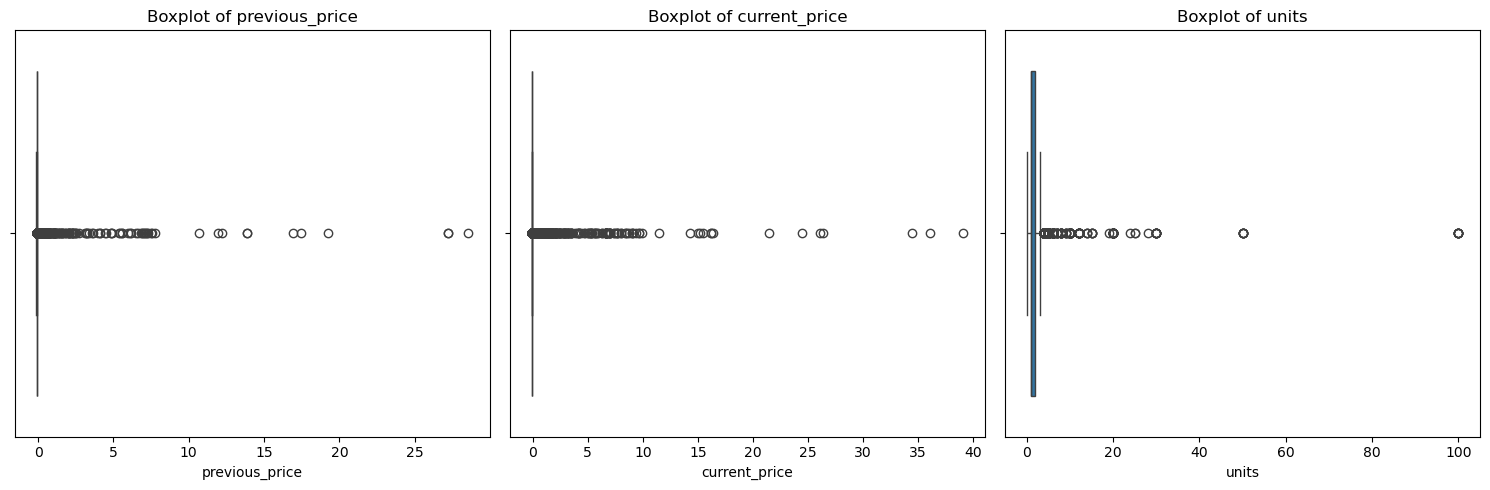

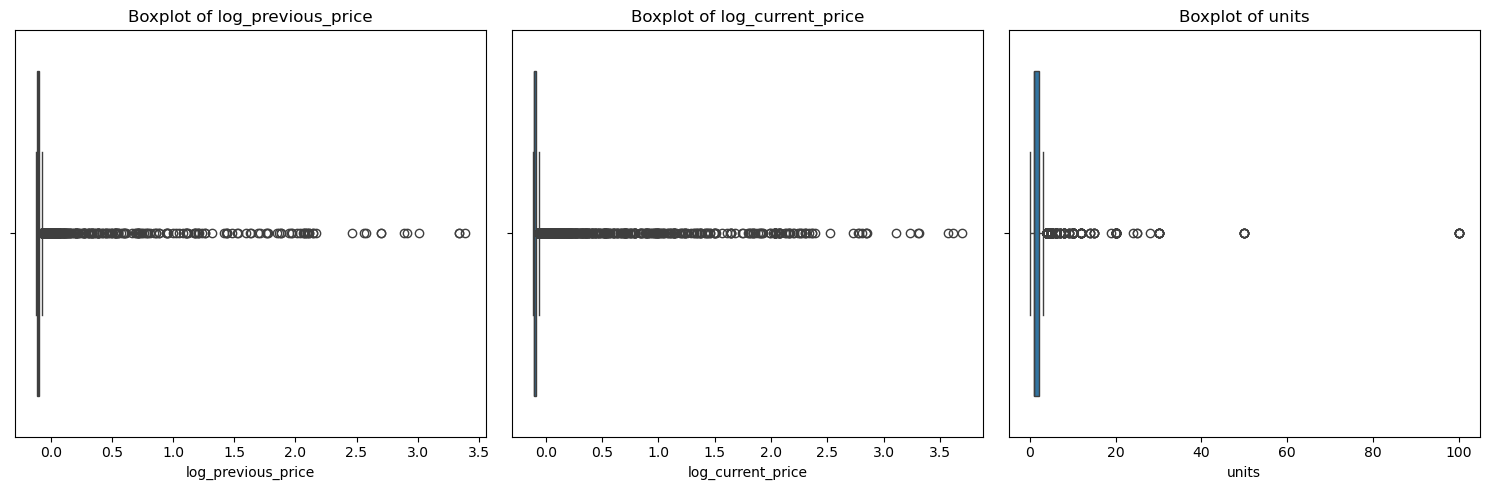

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1️⃣ عمل Log Transformation للأسعار
drug['log_previous_price'] = np.log1p(drug['previous_price'])
drug['log_current_price'] = np.log1p(drug['current_price'])


# 🔹 أولاً: Boxplot للأسعار الأصلية + units


original_cols = ['previous_price', 'current_price', 'units']

fig, axes = plt.subplots(1, 3, figsize=(15,5))

for i, col in enumerate(original_cols):
    sns.boxplot(x=drug[col], ax=axes[i])
    axes[i].set_title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()



# 🔹 ثانياً: Boxplot للأسعار بعد Log


log_cols = ['log_previous_price', 'log_current_price', 'units']

fig, axes = plt.subplots(1, 3, figsize=(15,5))

for i, col in enumerate(log_cols):
    sns.boxplot(x=drug[col], ax=axes[i])
    axes[i].set_title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

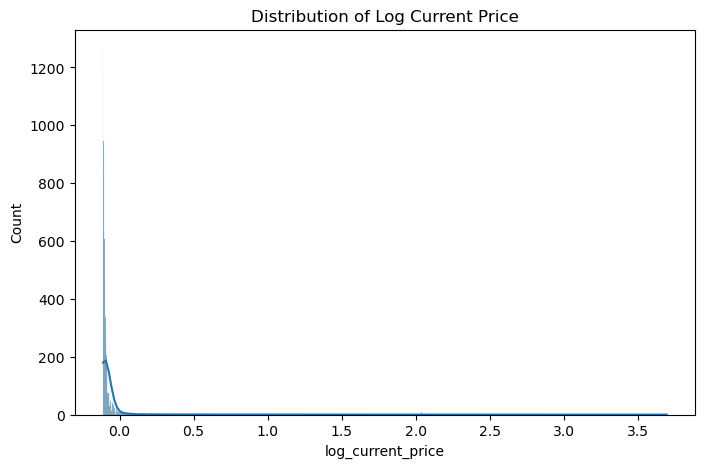

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(drug['log_current_price'], kde=True)
plt.title("Distribution of Log Current Price")
plt.show()

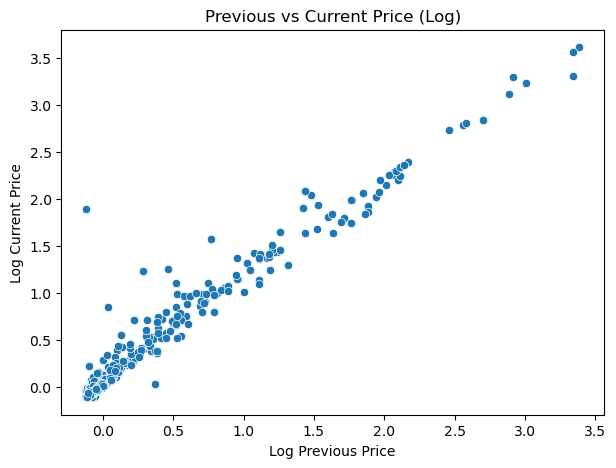

In [ ]:
plt.figure(figsize=(7,5))

sns.scatterplot(x=drug['log_previous_price'], 
                y=drug['log_current_price'])
plt.title("Previous vs Current Price (Log)")
plt.xlabel("Log Previous Price")
plt.ylabel("Log Current Price")

plt.show()

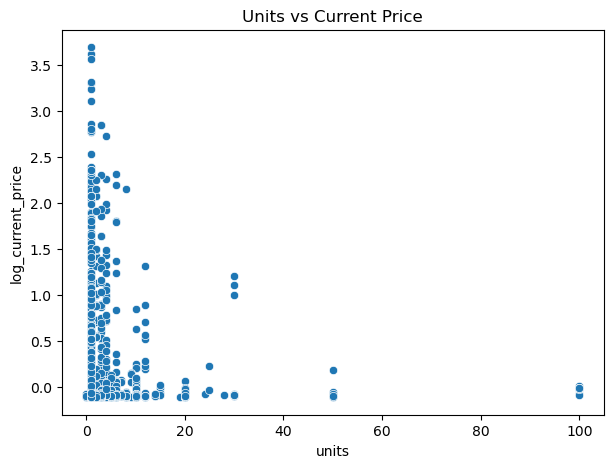

In [ ]:
plt.figure(figsize=(7,5))
sns.scatterplot(x=drug['units'], 
                y=drug['log_current_price'])
plt.title("Units vs Current Price")
plt.show()

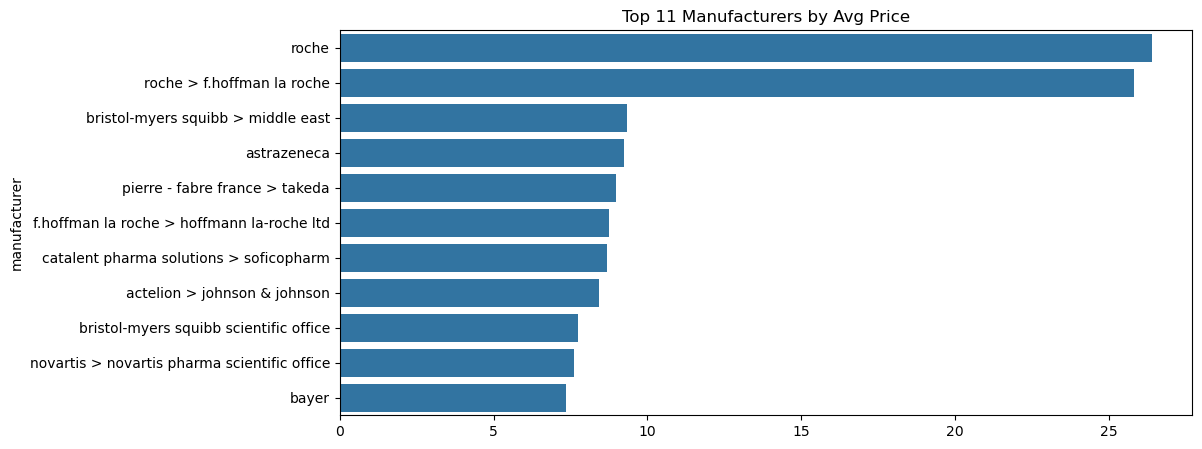

In [ ]:
top_manufacturer = (
    drug.groupby('manufacturer')['current_price']
    .mean()
    .sort_values(ascending=False)
    .head(11)
)

plt.figure(figsize=(11,5))
sns.barplot(x=top_manufacturer.values,
            y=top_manufacturer.index)
plt.title("Top 11 Manufacturers by Avg Price")
plt.show()

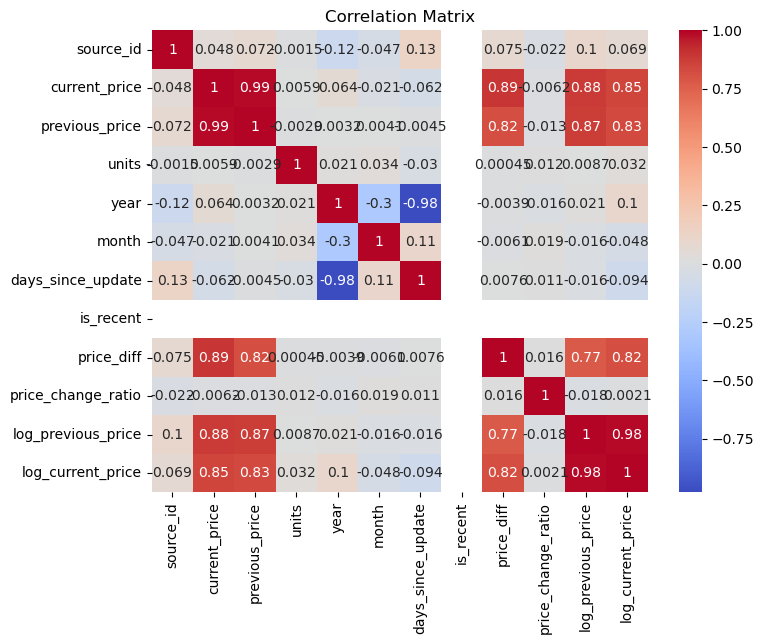

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(drug.select_dtypes(include=['float64','int64']).corr(),
            annot=True,
            cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

C:\Users\elgamal\AppData\Local\Temp\ipykernel_16268\2704492941.py:13: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_table = drug_top.pivot_table(


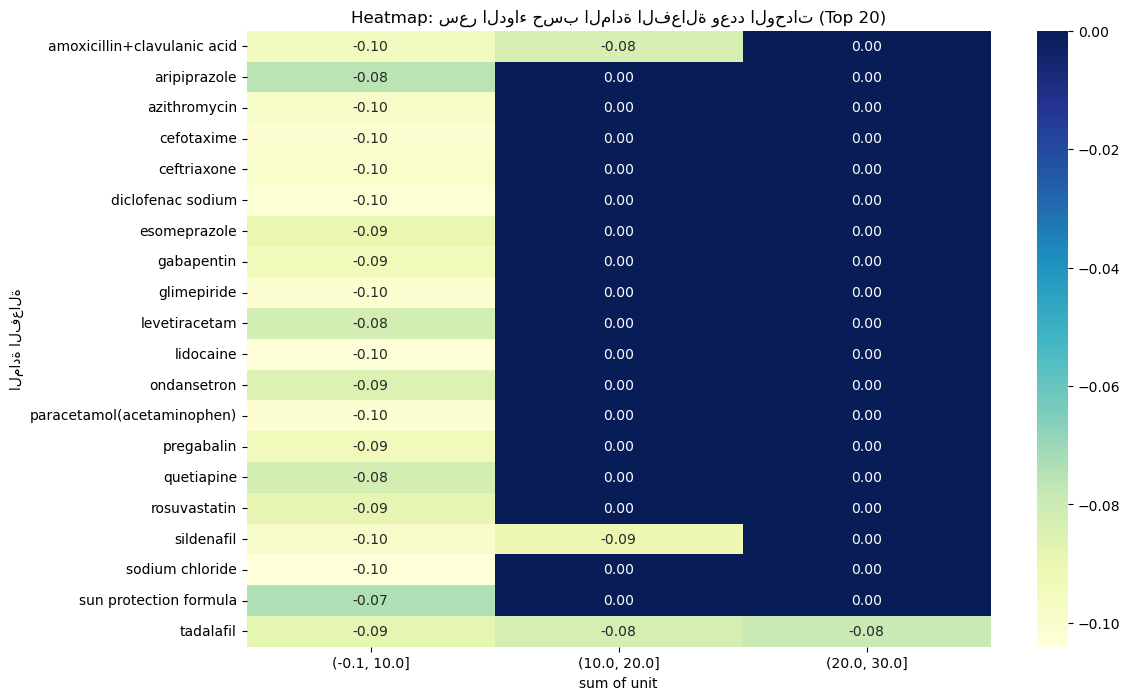

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# لو 'units' فيها قيم كتير، نعمل bins
drug['units_bin'] = pd.cut(drug['units'], bins=10)

# اختيار أفضل 20 مادة فعالة بالعدد
top_ingredients = drug['active_ingredients'].value_counts().nlargest(20).index
drug_top = drug[drug['active_ingredients'].isin(top_ingredients)]

# عمل pivot table
pivot_table = drug_top.pivot_table(
    index='active_ingredients',    # العمود الصح
    columns='units_bin',           # تقسيم عدد الوحدات لمجموعات
    values='current_price',        # العمود الصح للسعر
    aggfunc='mean',
    fill_value=0
)

# رسم Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(pivot_table, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Heatmap: سعر الدواء حسب المادة الفعالة وعدد الوحدات (Top 20)")
plt.ylabel("المادة الفعالة")
plt.xlabel("sum of unit")
plt.show()